<a href="https://colab.research.google.com/github/abdouertani/ML-Data-analysis/blob/main/data_analysis_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Dataset Generation



**Reasoning**:
Generate a synthetic cybersecurity dataset with intentional data quality issues such as missing values and duplicates as requested by the subtask instructions.



In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Set seed for reproducibility
np.random.seed(42)

# 1. Create synthetic data
n_rows = 220
start_time = datetime(2023, 1, 1)

data = {
    'Timestamp': [start_time + timedelta(hours=i*3) for i in range(n_rows)], # Spanning a wider time range
    'Source_IP': [f"192.168.1.{np.random.randint(1, 255)}" for _ in range(n_rows)],
    'Packet_Size': np.random.randint(40, 1500, size=n_rows).astype(float),
    'Login_Attempts': np.random.randint(1, 20, size=n_rows),
    'File_Encryption_Rate': np.random.uniform(0, 1, size=n_rows),
    'Threat_Type': np.random.choice(['Ransomware', 'DDoS', 'Phishing', 'Malware', 'Exploit', 'Clean'], size=n_rows, p=[0.15, 0.15, 0.1, 0.1, 0.1, 0.4]) # Added more threat types
}

# 2. Intentionally introduce missing values
# Missing values in 'Packet_Size'
mask_packet = np.random.choice([True, False], size=n_rows, p=[0.1, 0.9])
data['Packet_Size'][mask_packet] = np.nan

# Missing values in 'File_Encryption_Rate'
mask_encryption = np.random.choice([True, False], size=n_rows, p=[0.15, 0.85])
data['File_Encryption_Rate'][mask_encryption] = np.nan

# 3. Convert to DataFrame
df = pd.DataFrame(data)

# 4. Intentionally duplicate rows
duplicate_indices = np.random.choice(df.index, size=15, replace=False)
duplicates = df.loc[duplicate_indices]
df = pd.concat([df, duplicates], ignore_index=True)

# Display summary of issues and first few rows
print(f"Total rows: {len(df)}")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"Duplicate rows count: {df.duplicated().sum()}")

df.head(10)

Total rows: 235
Missing values:
Timestamp                0
Source_IP                0
Packet_Size             32
Login_Attempts           0
File_Encryption_Rate    37
Threat_Type              0
dtype: int64
Duplicate rows count: 15


,Timestamp,Source_IP,Packet_Size,Login_Attempts,File_Encryption_Rate,Threat_Type
0,2023-01-01 00:00:00,192.168.1.103,617.0,13,0.802109,Clean
1,2023-01-01 03:00:00,192.168.1.180,NaN,7,NaN,Clean
2,2023-01-01 06:00:00,192.168.1.93,596.0,4,0.556005,DDoS
3,2023-01-01 09:00:00,192.168.1.15,1052.0,13,0.322686,Clean
4,2023-01-01 12:00:00,192.168.1.107,685.0,1,NaN,Exploit
5,2023-01-01 15:00:00,192.168.1.72,835.0,8,0.924643,Clean
6,2023-01-01 18:00:00,192.168.1.189,1091.0,14,0.919116,Clean
7,2023-01-01 21:00:00,192.168.1.21,1403.0,16,NaN,Ransomware
8,2023-01-02 00:00:00,192.168.1.103,1394.0,14,0.695411,Exploit
9,2023-01-02 03:00:00,192.168.1.122,1411.0,12,0.075435,Clean


## Data Cleaning

### Subtask:
Handle missing values, remove duplicates, and ensure data integrity within the synthetic cybersecurity dataset.


**Reasoning**:
I will proceed with data cleaning by removing duplicates, imputing missing values for 'Packet_Size' and 'File_Encryption_Rate' as instructed, and verifying the data types and integrity.



In [ ]:
# 1. Remove duplicate rows and create a explicit copy to avoid SettingWithCopyWarning
df = df.drop_duplicates().copy()

# 2. Impute missing values in 'Packet_Size' with the median
packet_median = df['Packet_Size'].median()
df['Packet_Size'] = df['Packet_Size'].fillna(packet_median)

# 3. Fill missing values in 'File_Encryption_Rate' with 0
df['File_Encryption_Rate'] = df['File_Encryption_Rate'].fillna(0)

# 4. Verify cleaning results
print(f"Remaining missing values:\n{df.isnull().sum()}")
print(f"Remaining duplicate rows: {df.duplicated().sum()}")

# 5. Check and ensure correct data types
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
print("\nData Types:")
print(df.dtypes)

df.head()

Remaining missing values:
Timestamp               0
Source_IP               0
Packet_Size             0
Login_Attempts          0
File_Encryption_Rate    0
Threat_Type             0
dtype: int64
Remaining duplicate rows: 0

Data Types:
Timestamp               datetime64[ns]
Source_IP                       object
Packet_Size                    float64
Login_Attempts                   int64
File_Encryption_Rate           float64
Threat_Type                     object
dtype: object


,Timestamp,Source_IP,Packet_Size,Login_Attempts,File_Encryption_Rate,Threat_Type
0,2023-01-01 00:00:00,192.168.1.103,617.0,13,0.802109,Clean
1,2023-01-01 03:00:00,192.168.1.180,847.5,7,0.000000,Clean
2,2023-01-01 06:00:00,192.168.1.93,596.0,4,0.556005,DDoS
3,2023-01-01 09:00:00,192.168.1.15,1052.0,13,0.322686,Clean
4,2023-01-01 12:00:00,192.168.1.107,685.0,1,0.000000,Exploit


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Exploratory Data Analysis and Visualizations

### Subtask:
Generate visual representations of the cybersecurity data to understand feature distributions and relationships between threats.


**Reasoning**:
I will import the visualization libraries and create the requested EDA plots, including distributions of numerical features, a correlation heatmap, grouped box plots by threat type, and a scatter plot to identify patterns.



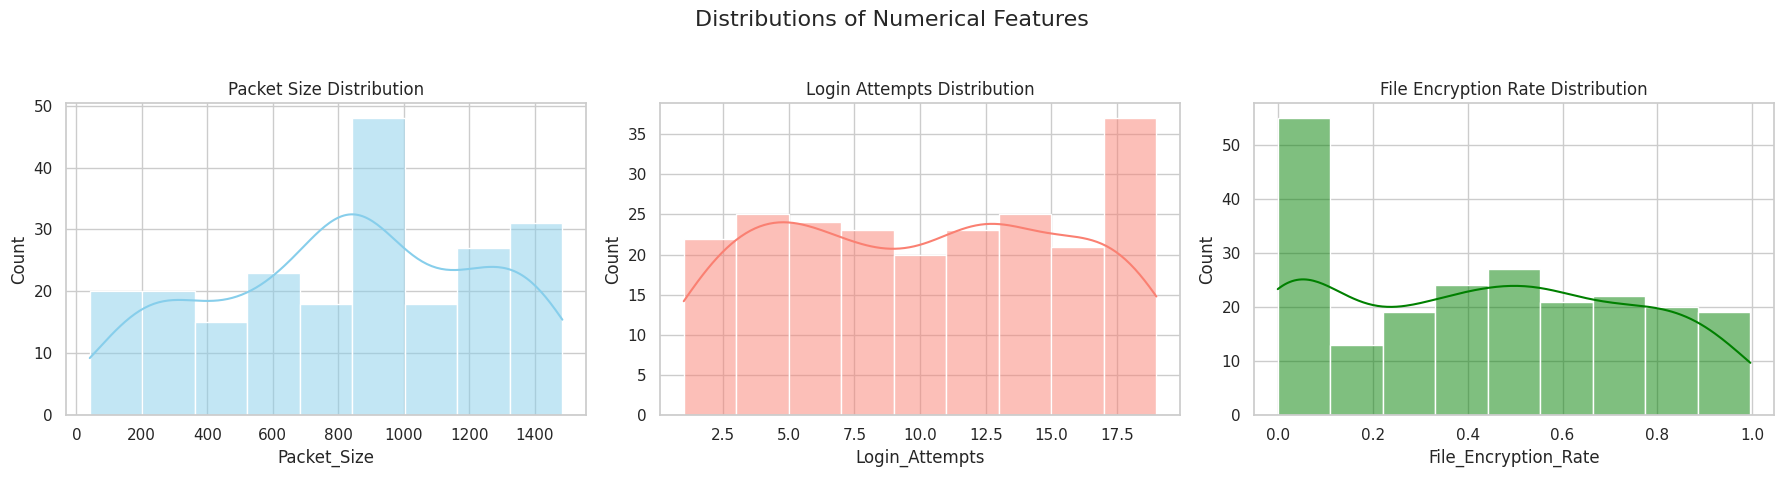

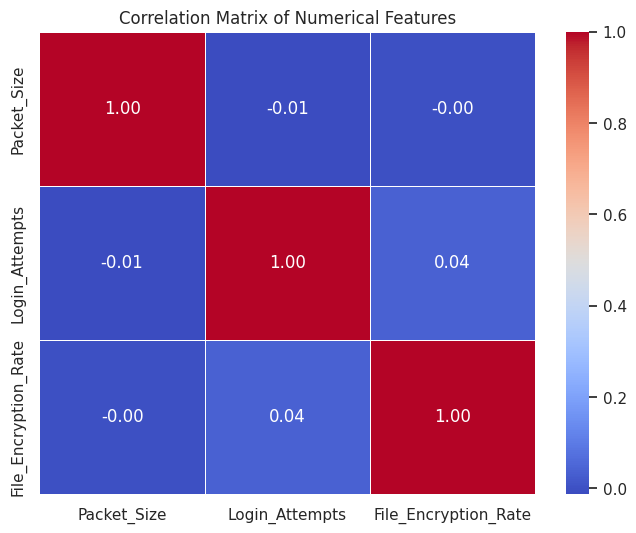

/tmp/ipykernel_13424/3065760606.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Threat_Type', y='File_Encryption_Rate', data=df, ax=axes[0], palette='Set2')
/tmp/ipykernel_13424/3065760606.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Threat_Type', y='Login_Attempts', data=df, ax=axes[1], palette='Set2')


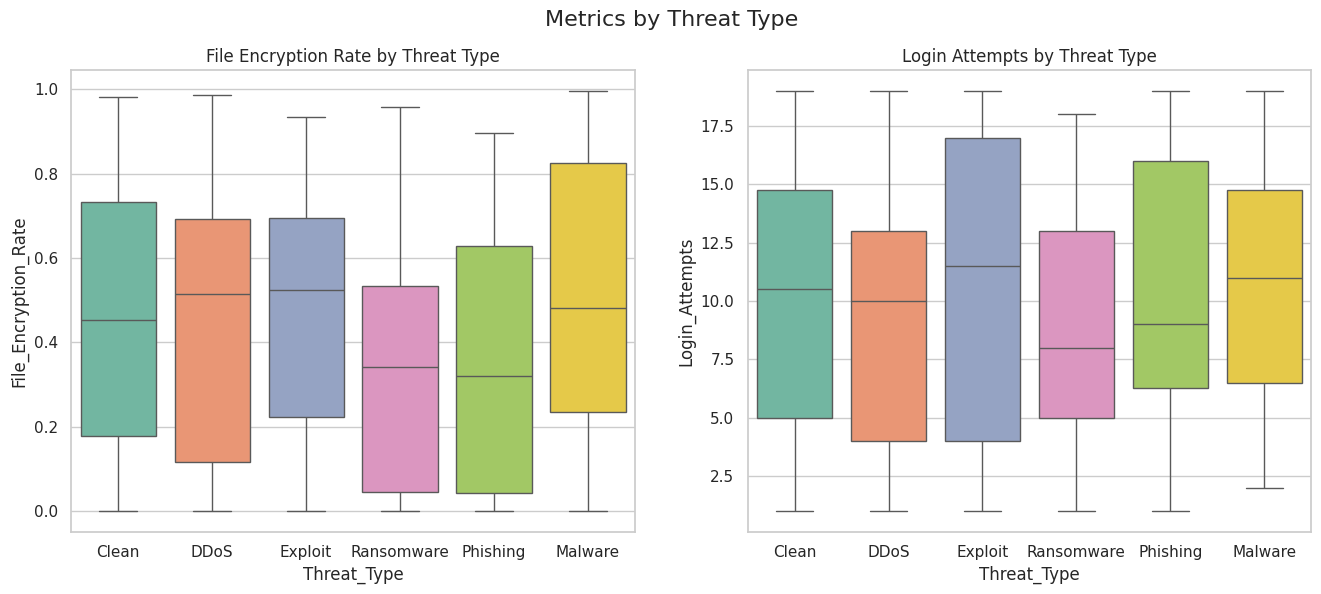

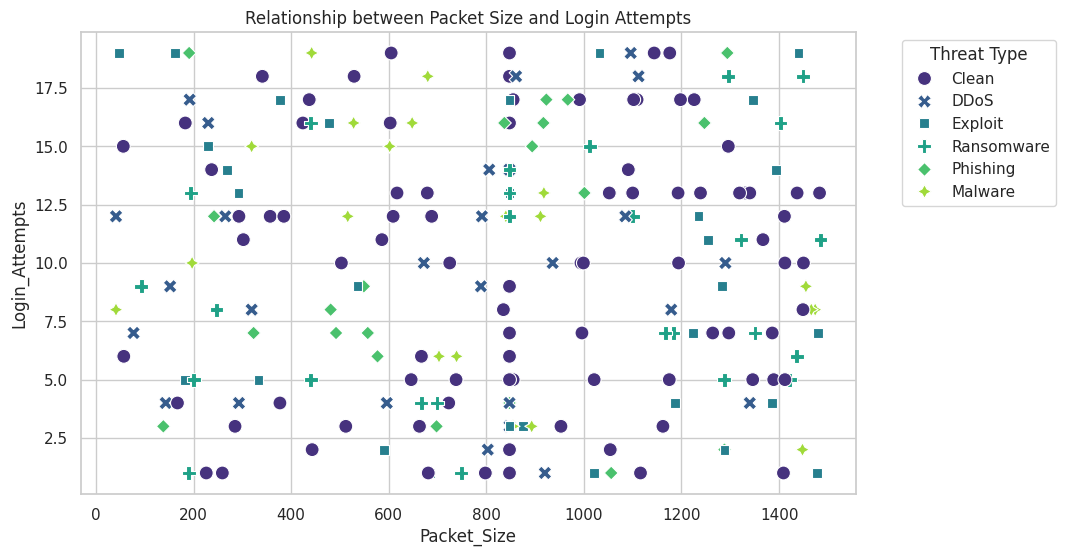

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic parameters for the plots
sns.set_theme(style="whitegrid")

# 1. Distribution of numerical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distributions of Numerical Features', fontsize=16)

sns.histplot(df['Packet_Size'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Packet Size Distribution')

sns.histplot(df['Login_Attempts'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Login Attempts Distribution')

sns.histplot(df['File_Encryption_Rate'], kde=True, ax=axes[2], color='green')
axes[2].set_title('File Encryption Rate Distribution')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 2. Correlation Matrix Heatmap
plt.figure(figsize=(8, 6))
numerical_cols = ['Packet_Size', 'Login_Attempts', 'File_Encryption_Rate']
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# 3. Box plots grouped by Threat_Type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Metrics by Threat Type', fontsize=16)

sns.boxplot(x='Threat_Type', y='File_Encryption_Rate', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('File Encryption Rate by Threat Type')

sns.boxplot(x='Threat_Type', y='Login_Attempts', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Login Attempts by Threat Type')

plt.show()

# 4. Scatter Plot: Packet_Size vs Login_Attempts colored by Threat_Type
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Packet_Size', y='Login_Attempts', hue='Threat_Type', style='Threat_Type', data=df, s=100, palette='viridis')
plt.title('Relationship between Packet Size and Login Attempts')
plt.legend(title='Threat Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Statistical Analysis

### Subtask:
Analyze feature dependencies and group-wise statistics to distinguish between 'Threat' (Ransomware, DDoS) and 'Clean' signatures.


**Reasoning**:
I will perform group-wise statistical analysis and subset correlation to identify the key indicators that distinguish threat types from clean traffic.



In [ ]:
import pandas as pd

# 1. Group data into 'Threat' vs 'Clean'
df['Is_Threat'] = df['Threat_Type'].apply(lambda x: 'Threat' if x in ['Ransomware', 'DDoS'] else 'Clean')

# 2. Calculate group-wise statistics
stats_cols = ['Packet_Size', 'Login_Attempts', 'File_Encryption_Rate']
group_stats = df.groupby('Threat_Type')[stats_cols].agg(['mean', 'median', 'std'])
print("--- Statistics Grouped by Threat Type ---")
print(group_stats)

# 3. Correlation analysis within Ransomware and DDoS subsets
print("\n--- Correlation within Ransomware Subset ---")
ransomware_corr = df[df['Threat_Type'] == 'Ransomware'][stats_cols].corr()
print(ransomware_corr)

print("\n--- Correlation within DDoS Subset ---")
ddos_corr = df[df['Threat_Type'] == 'DDoS'][stats_cols].corr()
print(ddos_corr)

# 4. Identify and print top indicators
print("\n--- Analysis of Key Threat Indicators ---")
clean_means = group_stats.loc['Clean', (slice(None), 'mean')]
for threat in ['Ransomware', 'DDoS']:
    threat_means = group_stats.loc[threat, (slice(None), 'mean')]
    print(f"\nIndicators for {threat} vs Clean:")
    for col in stats_cols:
        # Access values specifically to ensure they are scalars for formatting
        t_val = threat_means[col].iloc[0] if isinstance(threat_means[col], pd.Series) else threat_means[col]
        c_val = clean_means[col].iloc[0] if isinstance(clean_means[col], pd.Series) else clean_means[col]

        diff = t_val - c_val
        perc_diff = (diff / c_val) * 100
        print(f"- {col}: Average is {t_val:.2f} ({perc_diff:+.2f}% compared to Clean)")

--- Statistics Grouped by Threat Type ---
            Packet_Size                     Login_Attempts                   \
                   mean  median         std           mean median       std   
Threat_Type                                                                   
Clean        868.877778  847.50  384.740459      10.066667   10.5  5.656457   
DDoS         686.314815  803.00  397.770908       9.666667   10.0  5.306020   
Exploit      854.390625  847.50  454.157688      10.437500   11.5  6.530018   
Malware      789.545455  789.50  398.334685      10.454545   11.0  5.030642   
Phishing     743.954545  842.25  346.208886      10.272727    9.0  5.905460   
Ransomware   897.148148  847.50  458.713603       9.185185    8.0  5.030958   

            File_Encryption_Rate                      
                            mean    median       std  
Threat_Type                                           
Clean                   0.445068  0.452076  0.321431  
DDoS                    0.

## Feature Engineering

### Subtask:
Engineer a new derived feature, such as a 'Risk_Score', based on the combination of login attempts and encryption rates to enhance threat detection as requested.


**Reasoning**:
I will engineer the 'Risk_Score' feature by combining normalized login attempts and the file encryption rate, then evaluate its effectiveness by comparing averages across threat types.



In [ ]:
# 1. Create a derived Risk_Score
# We'll use a product-based approach: higher logins * higher encryption = higher risk
# We'll normalize Login_Attempts first to ensure balanced weighting
max_logins = df['Login_Attempts'].max()
df['Risk_Score'] = (df['Login_Attempts'] / max_logins) * df['File_Encryption_Rate']

# 2. Normalize Risk_Score to a 0-100 scale
score_min = df['Risk_Score'].min()
score_max = df['Risk_Score'].max()
df['Risk_Score'] = ((df['Risk_Score'] - score_min) / (score_max - score_min)) * 100

# 3. Display updated DataFrame and check group averages
print("First 5 rows with Risk_Score:")
print(df[['Threat_Type', 'Login_Attempts', 'File_Encryption_Rate', 'Risk_Score']].head())

print("\nAverage Risk_Score by Threat Type:")
risk_summary = df.groupby('Threat_Type')['Risk_Score'].mean().sort_values(ascending=False)
print(risk_summary)

First 5 rows with Risk_Score:
  Threat_Type  Login_Attempts  File_Encryption_Rate  Risk_Score
0       Clean              13              0.802109   59.392510
1       Clean               7              0.000000    0.000000
2        DDoS               4              0.556005   12.667576
3       Clean              13              0.322686   23.893447
4     Exploit               1              0.000000    0.000000

Average Risk_Score by Threat Type:
Threat_Type
Exploit       29.104446
Malware       26.524515
Clean         26.297896
DDoS          24.526282
Ransomware    18.515730
Phishing      18.363107
Name: Risk_Score, dtype: float64


### Export Data for Power BI

In [ ]:
import os

# Define the output directory for the CSV file
output_dir = 'power_bi_export'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Define the path for the CSV file
output_csv_path = os.path.join(output_dir, 'cybersecurity_data.csv')

# Save the DataFrame to a CSV file without the index
df.to_csv(output_csv_path, index=False)

print(f"Data saved to: {output_csv_path}")

Data saved to: power_bi_export/cybersecurity_data.csv
